# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

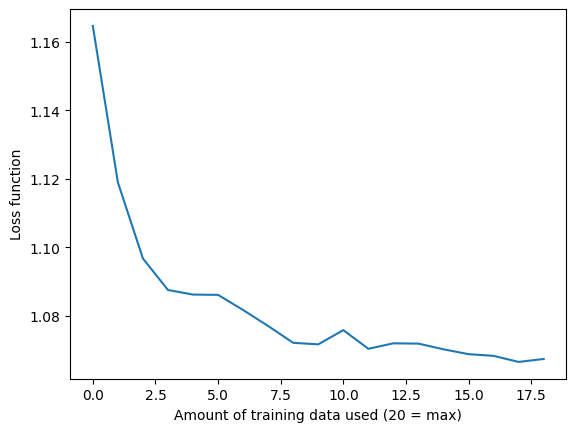

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

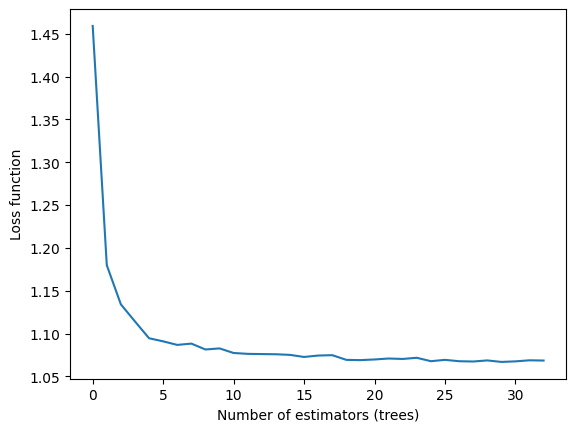

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

Between the two plots, I would remove the plot showing loss as a function of the number of estimators. While this plot provides some insight, it shows diminishing returns after a certain number of trees and does not significantly change the overall interpretation. In contrast, the plot showing loss as a function of the amount of training data used is more informative, as it highlights how model performance improves with more data and demonstrates the importance of dataset size.

The more important plot is the training data plot because it directly reflects how the model learns and generalizes. It shows a clear trend of decreasing loss as more data is introduced, which is a fundamental concept in machine learning.

The x-axis should represent the amount of training data used, as this provides a more meaningful and interpretable measure of model improvement compared to simply increasing the number of estimators.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Pre-Processing

In [8]:
# Download dataset
path2 = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:", path2)

instacart_dir = Path(path2)
print("Instacart dataset folder:", instacart_dir)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1
Instacart dataset folder: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1


In [9]:
# Load manageable files fully
orders = pd.read_csv(
    instacart_dir / "orders.csv",
    usecols=["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"]
)

products = pd.read_csv(instacart_dir / "products.csv")

print("orders shape:", orders.shape)
print("products shape:", products.shape)

display(orders.head())
display(products.head())

orders shape: (3421083, 6)
products shape: (49688, 4)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [10]:
# Sample a manageable subset of orders
sample_orders = orders.sample(n=10000, random_state=42)
sample_order_ids = set(sample_orders["order_id"].astype(int))

print("Number of sampled order IDs:", len(sample_order_ids))

# Load only matching rows from the large file using chunks
usecols = ["order_id", "product_id", "add_to_cart_order", "reordered"]

chunks = []
for chunk in pd.read_csv(
    instacart_dir / "order_products__prior.csv",
    usecols=usecols,
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
    chunksize=200_000
):
    filtered = chunk[chunk["order_id"].isin(sample_order_ids)]
    if not filtered.empty:
        chunks.append(filtered)

sample_order_products = pd.concat(chunks, ignore_index=True)

print("sample_order_products shape:", sample_order_products.shape)
display(sample_order_products.head())

Number of sampled order IDs: 10000
sample_order_products shape: (96603, 4)


,order_id,product_id,add_to_cart_order,reordered
0,322,13819,1,1
1,322,432,2,1
2,322,19311,3,1
3,322,36646,4,0
4,322,28842,5,1


In [11]:
# Merge sampled order-product data with product metadata
instacart_sample = sample_order_products.merge(products, on="product_id", how="left")

print("instacart_sample shape:", instacart_sample.shape)
display(instacart_sample.head())

instacart_sample shape: (96603, 7)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,322,13819,1,1,Roasted Salted Cashews,117,19
1,322,432,2,1,Vanilla Almond Breeze Almond Milk,91,16
2,322,19311,3,1,Almond Flour Tortillas,128,3
3,322,36646,4,0,Lactose Free Sour Cream,108,16
4,322,28842,5,1,Bunched Cilantro,16,4


In [12]:
# Basket size (items per order)
basket_size = instacart_sample.groupby("order_id").size().reset_index(name="basket_size")

# Reorder rate per order
reorder_rate = instacart_sample.groupby("order_id")["reordered"].mean().reset_index(name="reorder_rate")

# Average add-to-cart order
avg_add_to_cart = instacart_sample.groupby("order_id")["add_to_cart_order"].mean().reset_index(name="avg_add_to_cart_order")

# Merge with orders dataset
instacart_features = basket_size.merge(reorder_rate, on="order_id")
instacart_features = instacart_features.merge(avg_add_to_cart, on="order_id")
instacart_features = instacart_features.merge(orders, on="order_id")

# Clean dataset
instacart_features = instacart_features.dropna()
display(instacart_features.head())

,order_id,basket_size,reorder_rate,avg_add_to_cart_order,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,322,9,0.444444,5.0,36278,2,1,9,7.0
1,520,9,0.666667,5.0,165200,13,3,8,0.0
2,590,1,1.000000,1.0,198502,31,4,18,7.0
3,816,3,0.333333,2.0,112686,9,0,15,1.0
4,1084,14,0.642857,7.5,131593,41,0,12,7.0


### Modelling (Random Forest)

In [13]:
# Prepare Data
features = [
    "basket_size",
    "order_number",
    "days_since_prior_order",
    "order_hour_of_day"
]

X = instacart_features[features]
y = instacart_features["reorder_rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# Train Model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
rmse = root_mean_squared_error(y_test, preds)

print("RMSE:", rmse)

RMSE: 0.28172459273691575


In [15]:
# Hyperparameter Tuning (N-estimators)
rmse_list = []

for n in range(10, 110, 10):
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse_list.append(root_mean_squared_error(y_test, preds))

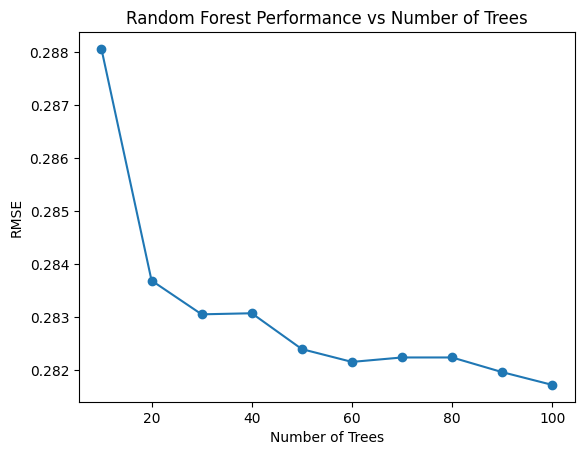

In [16]:
# Plot
import matplotlib.pyplot as plt

plt.plot(range(10, 110, 10), rmse_list, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.title("Random Forest Performance vs Number of Trees")
plt.show()

The plot shows how model performance changes as the number of trees in the Random Forest increases. There is a sharp decrease in RMSE when moving from 10 to around 20 trees, indicating that adding more trees initially improves model performance significantly. After this point, the improvement becomes more gradual, and the curve begins to level off. This suggests diminishing returns, where adding additional trees beyond approximately 50 to 70 provides only minimal performance gains. Overall, the model stabilizes as the number of trees increases, demonstrating that a moderate number of estimators is sufficient to achieve near-optimal performance. This also highlights the trade-off between computational cost and performance, as increasing the number of trees increases training time without significantly improving accuracy.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

There are no graphs in chapter 7 of the Storytelling With Data book. This is a graph from Chapter 8!


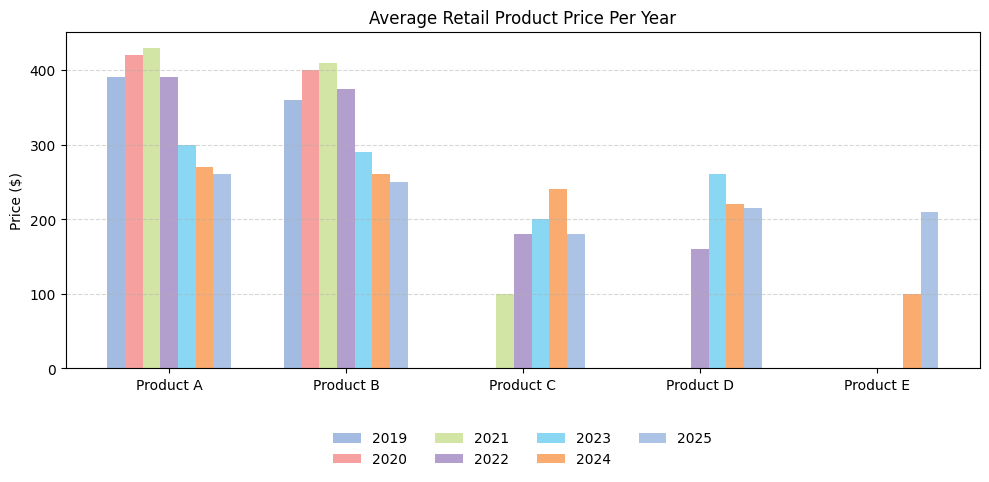

In [26]:
products = ["Product A", "Product B", "Product C", "Product D", "Product E"]

data = {
    "2019": [390, 360, 0, 0, 0],
    "2020": [420, 400, 0, 0, 0],
    "2021": [430, 410, 100, 0, 0],
    "2022": [390, 375, 180, 160, 0],
    "2023": [300, 290, 200, 260, 0],
    "2024": [270, 260, 240, 220, 100],
    "2025": [260, 250, 180, 215, 210]
}

years = list(data.keys())
values = list(data.values())

x = np.arange(len(products))
width = 0.1

# Color palette
colors = [
    "#A3BBE1",  
    "#F6A09F",  
    "#D2E5A5",  
    "#B39FCD",  
    "#8AD7F4",  
    "#FAAB6F",  
    "#ACC3E5"   
]

plt.figure(figsize=(10,5))

# Plot bars
for i, year in enumerate(years):
    plt.bar(x + i*width, values[i], width=width, color=colors[i], label=year)

# Labels
plt.xticks(x + width*3, products)
plt.ylabel("Price ($)")
plt.title("Average Retail Product Price Per Year")

# Legend
plt.legend(
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=4,
    frameon=False
)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()